<a href="https://colab.research.google.com/github/clara-eng/My-AI-Journey/blob/main/Stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_wine
import pandas as pd



In [ ]:
# Load wine dataset
wine = load_wine()
X, y = wine.data, wine.target



In [ ]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Create a Decision Tree model without Stacking for comparison
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
base_accuracy = accuracy_score(y_test, y_pred_base)


In [ ]:

# Define base models for stacking
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),  # Decision Tree
    ('knn', KNeighborsClassifier(n_neighbors=5)),                 # KNN
    ('svm', SVC(probability=True, kernel='linear', random_state=42))  # SVM
]

# Define the meta-learner (final model)
meta_learner = LogisticRegression()

# Create the Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,  # Base models
    final_estimator=meta_learner,  # Meta model
    passthrough=False,  # Use original features + predictions from base models
    cv=5  # Cross-validation
)

# Train the Stacking model on the training data
stacking_model.fit(X_train, y_train)



StackingClassifier(cv=5,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svm',
                                SVC(kernel='linear', probability=True,
                                    random_state=42))],
                   final_estimator=LogisticRegression())

In [ ]:
# Make predictions on the test set
y_pred_stacking = stacking_model.predict(X_test)

# Compute Accuracy
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)

# Print results
print(f"📌 Accuracy of Decision Tree without Stacking: {base_accuracy:.4f}")
print(f"✅ Accuracy of Stacking (DT, KNN, SVM + Logistic Regression): {stacking_accuracy:.4f}")



📌 Accuracy of Decision Tree without Stacking: 0.9444
✅ Accuracy of Stacking (DT, KNN, SVM + Logistic Regression): 0.9722


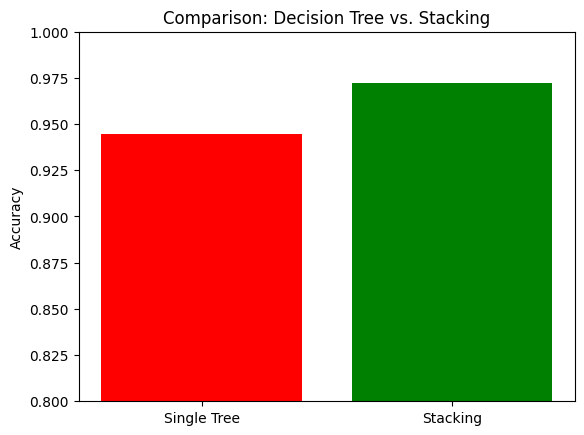

In [ ]:
# Performance comparison
labels = ['Single Tree', 'Stacking']
accuracies = [base_accuracy, stacking_accuracy]

plt.bar(labels, accuracies, color=['red', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparison: Decision Tree vs. Stacking')
plt.ylim(0.8, 1)  # Adjust scale
plt.show()
